In [ ]:
!pip install numpy
!pip install matplotlib

In [ ]:
!pip install datasets scikit-learn gensim nltk pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 55.5 MB/s eta 0:00:00


1. LOAD DATA

In [ ]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split


# ==========================================
# We use engine='python' and on_bad_lines='skip' to handle potential CSV formatting errors
try:
    df = pd.read_csv('train.csv', on_bad_lines='skip', engine='python')
except FileNotFoundError:
    # Create dummy data if you don't have the file locally for testing
    print("File not found. Creating dummy data.")
    df = pd.DataFrame({'text': [
        "The quick brown fox jumps over the lazy dog",
        "Stock market crash causes panic in global economy",
        "New technology breakthrough in artificial intelligence",
        "Sports team wins championship after dramatic final game"
    ]})

# Sample for speed if dataset is large
if len(df) > 1000:
    df = df.sample(1000, random_state=42).reset_index(drop=True)




2. PREPROCESS

In [ ]:
# Manual stopword list to avoid NLTK download dependencies
STOPWORDS = set(['the', 'and', 'to', 'of', 'a', 'in', 'is', 'that', 'for', 'it', 'on', 'with', 'as', 'was', 'at', 'by', 'an', 'be', 'this', 'from'])

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', '', text) # Remove punctuation
    # Keep words > 2 chars and not in stopword list
    return " ".join([w for w in text.split() if w not in STOPWORDS and len(w) > 2])

# Handle if column is named 'text' or something else
text_col = 'text' if 'text' in df.columns else df.columns[0]
df['clean_text'] = df[text_col].apply(clean_text)

3. GENERATE EMBEDDINGS (For the first document)

In [ ]:
doc_idx = 0
print(f"Visualizing Document #{doc_idx}: \n{df['clean_text'][doc_idx][:100]}...\n")

Visualizing Document #0: 
bbc set major shakeup claims newspaper london british broadcasting corporation world biggest public ...



 A. One-Hot (Binary)

In [ ]:
# binary=True means we only care if word is present (1) or not (0)
cv_binary = CountVectorizer(binary=True, max_features=20)
onehot_vec = cv_binary.fit_transform(df['clean_text'])
row_onehot = onehot_vec[doc_idx].toarray()[0]
feat_names = cv_binary.get_feature_names_out()
print(f"1. One-Hot Matrix: {onehot_vec.shape}  (Rows, Vocabulary Size)")

1. One-Hot Matrix: (1000, 20)  (Rows, Vocabulary Size)


 B. Bag of Words (Counts)

In [ ]:
# Default behavior counts frequencies
cv_bow = CountVectorizer(max_features=20)
bow_vec = cv_bow.fit_transform(df['clean_text'])
row_bow = bow_vec[doc_idx].toarray()[0]
print(f"2. Bag of Words:   {bow_vec.shape}  (Rows, Vocabulary Size)")

2. Bag of Words:   (1000, 20)  (Rows, Vocabulary Size)


C. TF-IDF (Weighted)

In [ ]:
tfidf = TfidfVectorizer(max_features=20)
tfidf_vec = tfidf.fit_transform(df['clean_text'])
row_tfidf = tfidf_vec[doc_idx].toarray()[0]
feat_names_tfidf = tfidf.get_feature_names_out()
print(f"3. TF-IDF Matrix:  {tfidf_vec.shape}  (Rows, Vocabulary Size)")

3. TF-IDF Matrix:  (1000, 20)  (Rows, Vocabulary Size)


D. Dense (LSA - Proxy for Word2Vec/GloVe)

In [ ]:
# We calculate on full vocab then reduce to 10 dimensions
tfidf_full = TfidfVectorizer(max_features=1000)
full_vec = tfidf_full.fit_transform(df['clean_text'])
svd = TruncatedSVD(n_components=10, random_state=42)
dense_vec = svd.fit_transform(full_vec)
row_dense = dense_vec[doc_idx]
print(f"4. Dense Matrix:   {dense_vec.shape}  (Rows, Dimensions)")

4. Dense Matrix:   (1000, 10)  (Rows, Dimensions)


4. VISUALIZATION

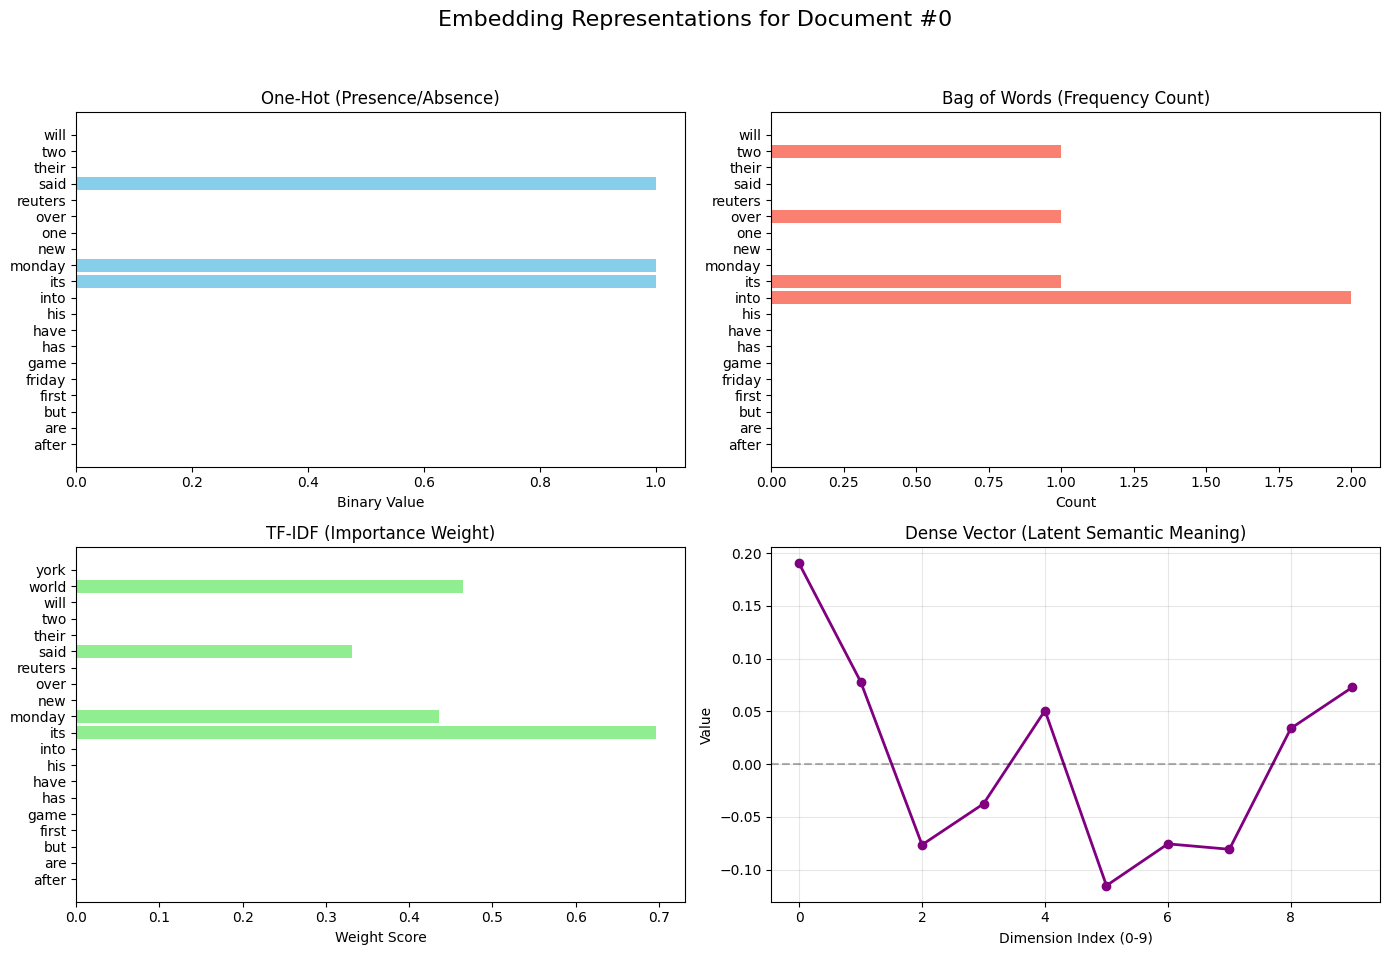

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Embedding Representations for Document #{doc_idx}', fontsize=16)

# Plot 1: One-Hot
axes[0, 0].barh(feat_names, row_onehot, color='skyblue')
axes[0, 0].set_title('One-Hot (Presence/Absence)')
axes[0, 0].set_xlabel('Binary Value')

# Plot 2: Bag of Words
axes[0, 1].barh(feat_names, row_bow, color='salmon')
axes[0, 1].set_title('Bag of Words (Frequency Count)')
axes[0, 1].set_xlabel('Count')

# Plot 3: TF-IDF
axes[1, 0].barh(feat_names_tfidf, row_tfidf, color='lightgreen')
axes[1, 0].set_title('TF-IDF (Importance Weight)')
axes[1, 0].set_xlabel('Weight Score')

# Plot 4: Dense Vector
axes[1, 1].plot(range(len(row_dense)), row_dense, marker='o', linestyle='-', color='purple', linewidth=2)
axes[1, 1].set_title('Dense Vector (Latent Semantic Meaning)')
axes[1, 1].set_xlabel('Dimension Index (0-9)')
axes[1, 1].set_ylabel('Value')
axes[1, 1].grid(True, alpha=0.3)
# Add a zero line for reference
axes[1, 1].axhline(y=0, color='k', linestyle='--', alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
import os
import requests
import zipfile

# Constants
GLOVE_URL = "https://nlp.stanford.edu/data/glove.6B.zip"
ZIP_FILE = "glove.6B.zip"
TARGET_FILE = "glove.6B.100d.txt"

def download_glove():
    # 1. Check if the text file already exists
    if os.path.exists(TARGET_FILE):
        print(f"✅ Found '{TARGET_FILE}'. Skipping download.")
        return

    # 2. Check if zip already exists (to avoid re-downloading)
    if not os.path.exists(ZIP_FILE):
        print(f"⬇️  Downloading GloVe vectors (approx 800MB)... please wait.")
        try:
            response = requests.get(GLOVE_URL, stream=True)
            response.raise_for_status() # Check for errors

            with open(ZIP_FILE, 'wb') as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            print("✅ Download complete.")
        except Exception as e:
            print(f"❌ Download failed: {e}")
            return

    # 3. Unzip only the specific 100d file
    print(f"📂 Extracting '{TARGET_FILE}' from zip...")
    try:
        with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
            zip_ref.extract(TARGET_FILE, path=".")
        print(f"✅ Extraction complete! You can now run the GloVe code.")

        # Optional: Remove the zip file to save space
        # os.remove(ZIP_FILE)

    except Exception as e:
        print(f"❌ Extraction failed: {e}")

if __name__ == "__main__":
    download_glove()

✅ Found 'glove.6B.100d.txt'. Skipping download.



Generating document vectors...
------------------------------
GloVe Matrix Shape: (1000, 100)
------------------------------
Generating PCA Plot...


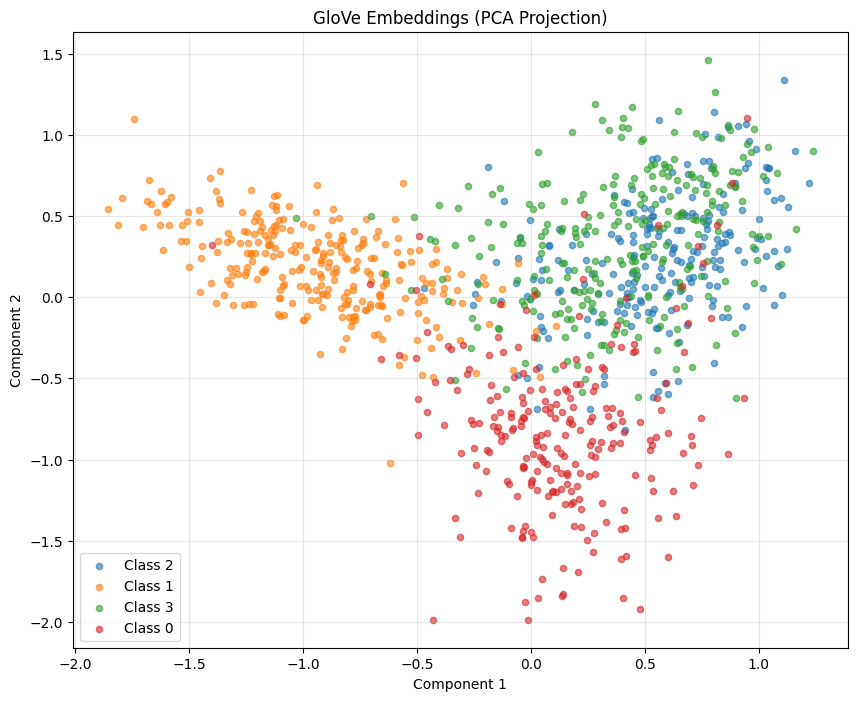

Plot saved as 'glove_plot.png'


In [ ]:
from sklearn.decomposition import PCA

def get_glove_vector(clean_string, model, vector_size=100):
    # CRITICAL STEP: We must split the string back into a list of words
    tokens = clean_string.split()

    valid_vectors = [model[word] for word in tokens if word in model]
    if not valid_vectors:
        return np.zeros(vector_size)
    return np.mean(valid_vectors, axis=0)

if embeddings_index:
    print("\nGenerating document vectors...")
    # Apply to the 'clean_text' column
    X_glove = np.array([get_glove_vector(text, embeddings_index, 100) for text in df['clean_text']])

    print("-" * 30)
    print(f"GloVe Matrix Shape: {X_glove.shape}")
    print("-" * 30)

    # 5. VISUALIZATION
    # ================
    print("Generating PCA Plot...")
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_glove)

    plt.figure(figsize=(10, 8))

    # Color by label if available
    if 'label' in df.columns:
        labels = df['label'].unique()
        for label in labels:
            indices = df['label'] == label
            plt.scatter(X_2d[indices, 0], X_2d[indices, 1], label=f"Class {label}", alpha=0.6, s=20)
        plt.legend()
    else:
        plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5)

    plt.title('GloVe Embeddings (PCA Projection)')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.grid(True, alpha=0.3)

    # Save/Show
    plt.savefig('glove_plot.png')
    plt.show()
    print("Plot saved as 'glove_plot.png'")
else:
    print("Skipping embeddings generation (GloVe vectors missing).")

In [ ]:
if 'label' in df.columns:
    print("Class distribution in the dataset:")
    display(df['label'].value_counts())
    print("\nUnique labels:", df['label'].unique())
else:
    print("No 'label' column found in the DataFrame to explain classes.")

Class distribution in the dataset:


,count
label,
1,277
3,261
0,236
2,226



Unique labels: [2 1 3 0]


In [ ]:
df.head()

,text,label,clean_text
0,"BBC set for major shake-up, claims newspaper L...",2,bbc set major shakeup claims newspaper london ...
1,Marsh averts cash crunch Embattled insurance b...,2,marsh averts cash crunch embattled insurance b...
2,"Jeter, Yankees Look to Take Control (AP) AP - ...",1,jeter yankees look take control derek jeter tu...
3,Flying the Sun to Safety When the Genesis caps...,3,flying sun safety when genesis capsule comes b...
4,Stocks Seen Flat as Nortel and Oil Weigh NEW ...,2,stocks seen flat nortel oil weigh new york reu...
